In [1]:
import numpy as np
# import pandas as pd

import matplotlib.pyplot as plt
import re
from pathlib import Path
import string
import pickle

from functools import partial

In [2]:
# from imblearn.pipeline import Pipeline # supports for oversampling step
# from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
from sklearn.model_selection import (
    StratifiedKFold,
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    train_test_split)
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_curve, 
    roc_auc_score,
    f1_score)

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression  # TODO we can also use this
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

# from xgboost import XGBClassifier

from sklearn.decomposition import TruncatedSVD

# from imblearn.over_sampling import RandomOverSampler, SMOTE
# from imblearn.under_sampling import RandomUnderSampler

In [3]:
from rital.data import (
    load_presidents,
    load_presidents_unseen,
)
from rital.preprocessing import (
    compute_odds_ratio,
    plot_frequencies,
    plot_word_cloud
)

from rital.presidents.preprocessing import (
    preprocess,
    tokenizer
)

from rital.presidents.analysis import (
    plot_roc_pr,
    ordered_train_test_split,
    plot_train_test_cm,
    TextStats
)

from rital.presidents.postprocessing import (
    smooth,
    plot_smoothing,
    calibrate_proba,
    adjust_threshold,
    adjust_proba,
    SmoothLogisticRegression
)
%load_ext autoreload
%autoreload 2

In [4]:
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords
STEMMER = SnowballStemmer("french")
STOP_WORDS = stopwords.words("french")

## Data Loading

In [5]:
X_train_full, y_train_full = load_presidents()
X_test_unseen = load_presidents_unseen()
label2name = {
    0 : "Chirac",
    1 : "Mitterrand"
}
X_train_full_embeddings = np.load("X_train_full_embeddings.npy")

## Train-test split preserving order

In [6]:
FIT_ON_UNSEEN = False
if FIT_ON_UNSEEN:
    X_train = X_train_full
    y_train = y_train_full
    X_test = X_test_unseen
    y_test = None # Unseen
    
    X_test_embeddings = None  # X_test_unseen_embeddings # Not done yet
    X_train_embeddings = X_train_full_embeddings

else:    
    X_train, X_train_embeddings, y_train, X_test, X_test_embeddings, y_test = ordered_train_test_split(
        X_train_full, y_train_full, X_train_full_embeddings,
        test_size=0.2, random_state=2, 
        shuffle = False,
        stratify=False
        )
    print(f"Original imbalance: { (y_train_full == 0).sum() / (y_train_full == 1).sum() :.2f}")
    print(f"Train imbalance: {(y_train == 0).sum() / (y_train == 1).sum() :.2f}")
    print(f"Test imbalance: {(y_test == 0).sum() / (y_test == 1).sum() :.2f}")
    # NOTE: test set is less balanced, so performance is underestimated

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', 
                                    classes=classes, 
                                    y=y_train)
class_weight_dict = {cls: w for cls, w in zip(classes, class_weights)}
sample_weights = np.array([class_weight_dict[y] for y in y_train])

Original imbalance: 6.63
Train imbalance: 6.22
Test imbalance: 8.87


# Try RNN

In [43]:
import re

In [44]:
tokens = set()
for doc in X_train_full:
    doc = doc.lower()
    doc = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ0-9\s]", "", doc)
    for token in doc.split():
        tokens.add(token)
tokens = ["<pad>", "<unk>"] + list(tokens)
vocab = dict(zip(tokens, range(len(tokens))))

In [45]:
import torch
from torch.utils.data import Dataset

class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=50):
        self.texts = texts
        self.labels = torch.from_numpy(labels).float()
        self.vocab = vocab
        self.max_len = max_len

    def encode(self, text):
        tokens = text.lower().split()
        ids = [self.vocab.get(t, self.vocab["<unk>"]) for t in tokens]
        
        # padding / truncation
        ids = ids[:self.max_len]
        ids += [self.vocab["<pad>"]] * (self.max_len - len(ids))
        return torch.tensor(ids).long()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = self.encode(self.texts[idx])
        y = self.labels[idx]
        return x, y

train_dataset = TextDataset(X_train, y_train,vocab)
test_dataset = TextDataset(X_test, y_test,vocab)

In [46]:
import torch.nn as nn

class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        self.rnn = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.embedding(x)              # (B, T) → (B, T, E)
        _, h = self.rnn(x)                # h: (1, B, H)
        h = h.squeeze(0)                 # (B, H)
        out = self.fc(h)                 # (B, 1)
        return out.squeeze(1)            # (B,)

In [47]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    xs, ys = zip(*batch)
    xs_padded = pad_sequence(xs, batch_first=True, padding_value=0)  # 0 = <pad>
    ys = torch.stack(ys)
    return xs_padded, ys

In [48]:
from rital.presidents.analysis import plot_roc_pr, plot_train_test_cm
from rital.presidents.postprocessing import smooth, adjust_proba

/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_55105/4230795615.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pos_weight = torch.tensor(num_neg / num_pos, dtype=torch.float32)
Training epoch 0: 100%|██████████| 1436/1436 [00:22<00:00, 63.69it/s]


Epoch 0 - loss: 0.2241


Evaluation epoch 0: 100%|██████████| 12/12 [00:00<00:00, 12.06it/s]


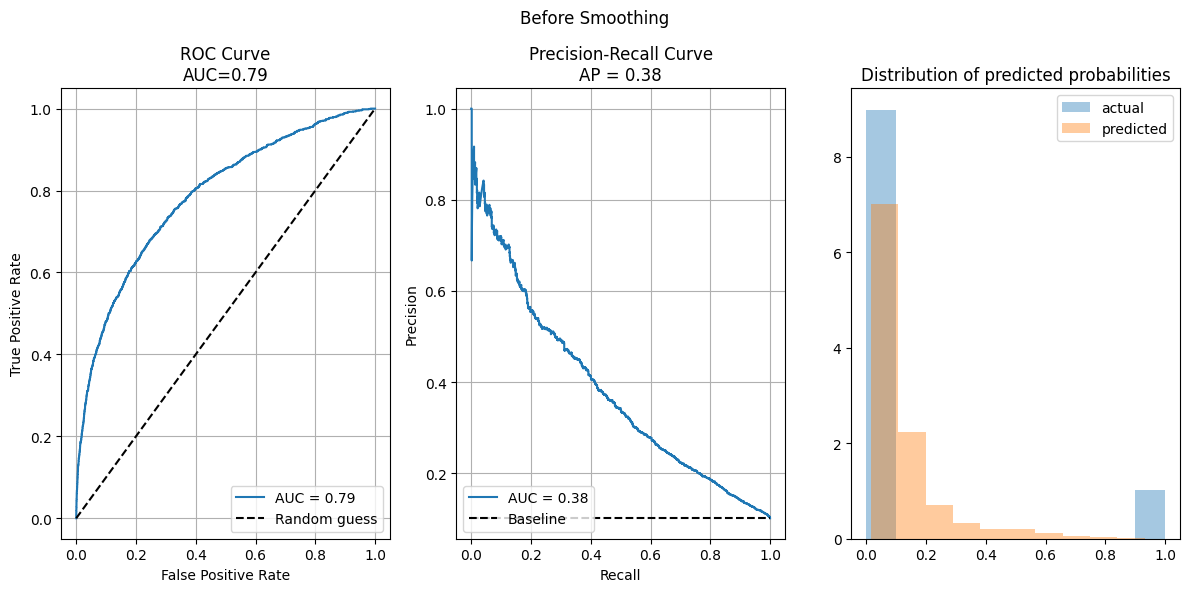

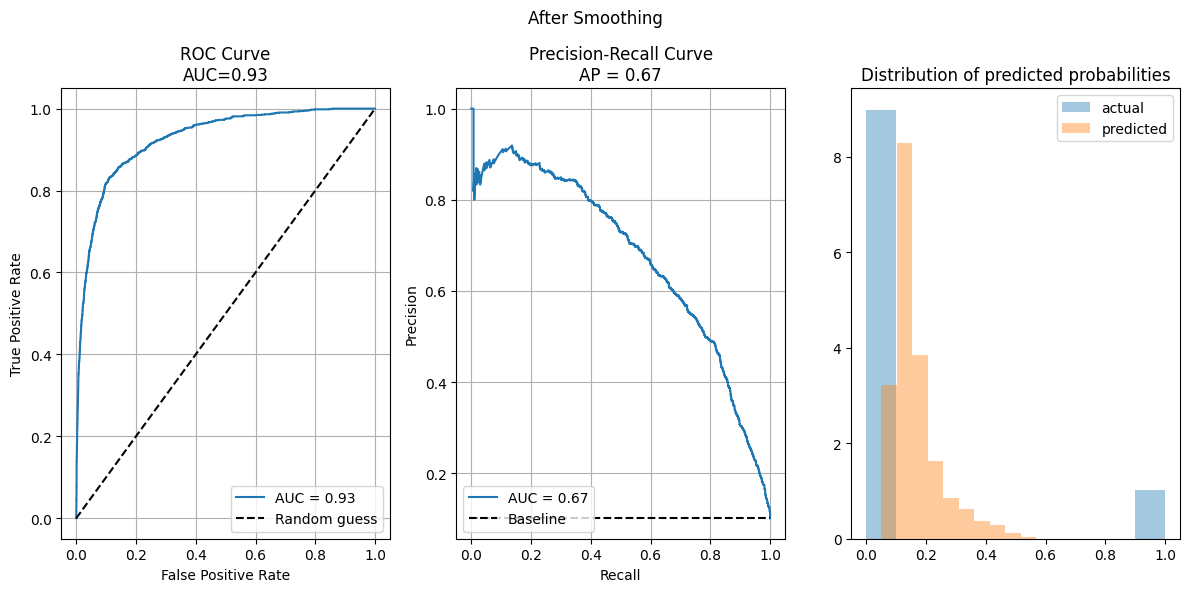

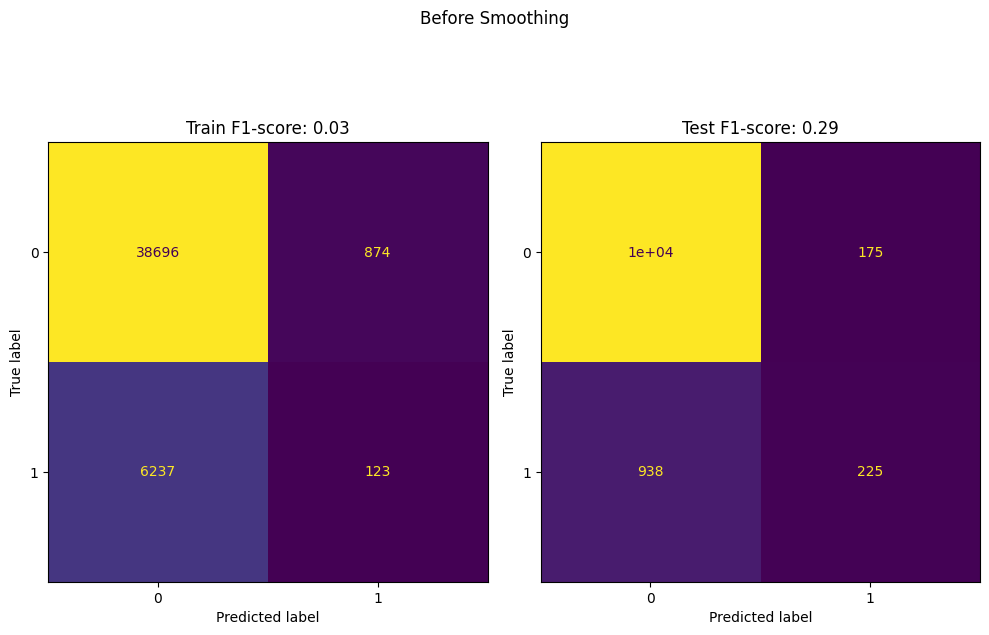

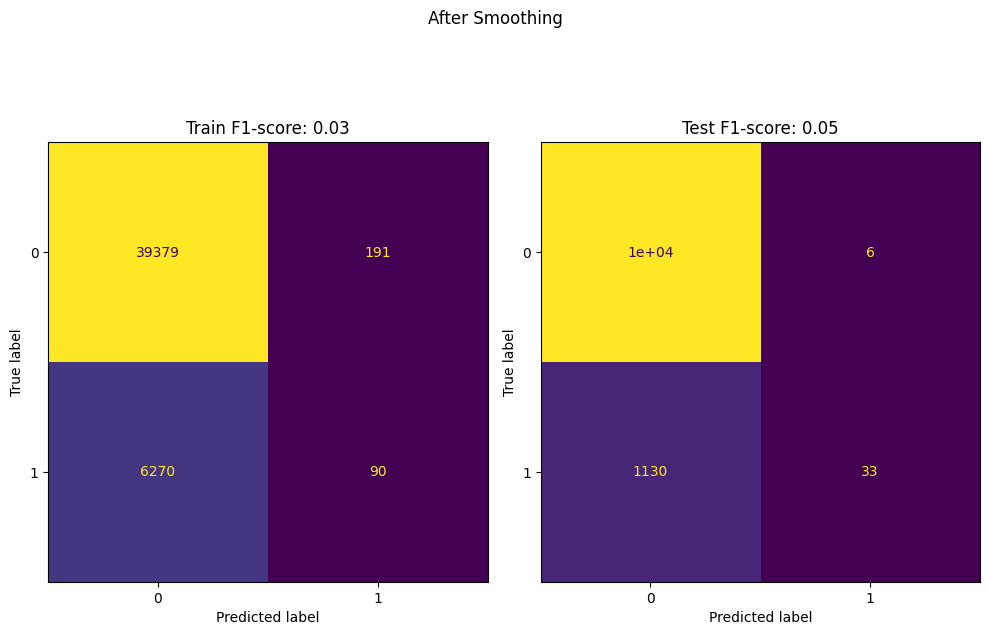

Training epoch 1: 100%|██████████| 1436/1436 [00:21<00:00, 65.49it/s]


Epoch 1 - loss: 0.4192


Training epoch 2: 100%|██████████| 1436/1436 [00:26<00:00, 54.91it/s]


Epoch 2 - loss: 0.1045


Training epoch 3: 100%|██████████| 1436/1436 [00:21<00:00, 66.82it/s]


...

Training epoch 4: 100%|██████████| 1436/1436 [00:21<00:00, 65.61it/s]


Epoch 4 - loss: 0.1526


Training epoch 5: 100%|██████████| 1436/1436 [00:21<00:00, 66.89it/s]


Epoch 5 - loss: 0.0128


Evaluation epoch 5: 100%|██████████| 12/12 [00:00<00:00, 14.96it/s]


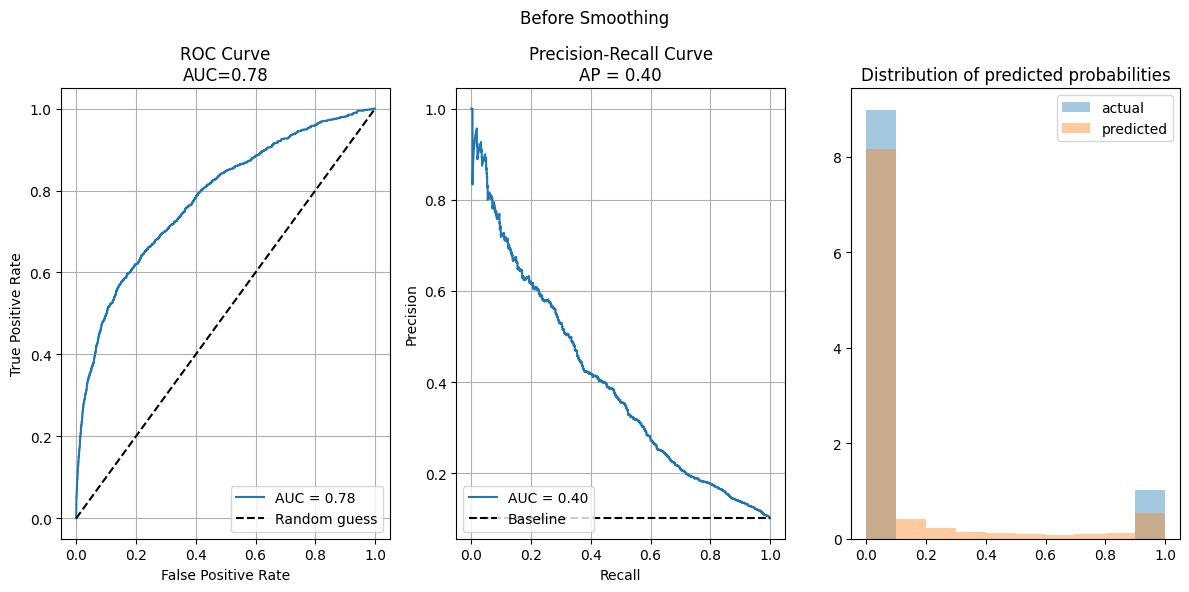

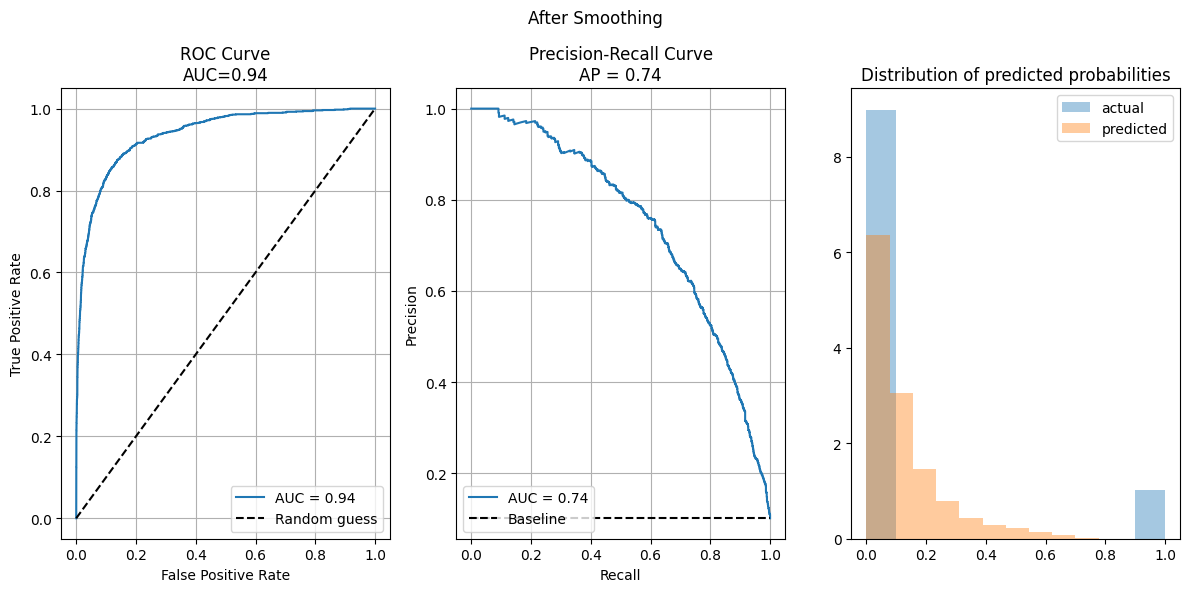

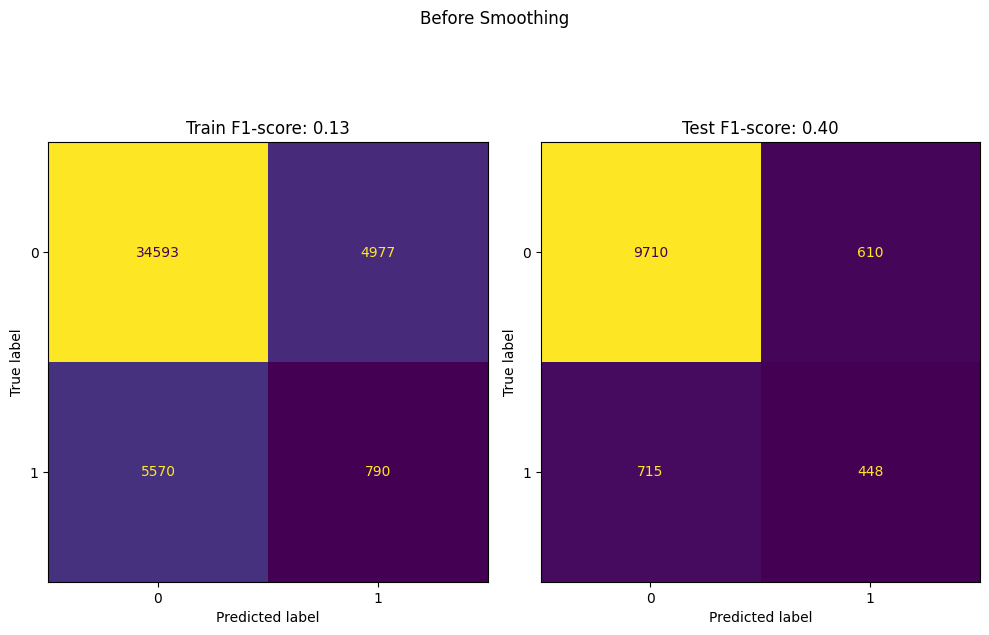

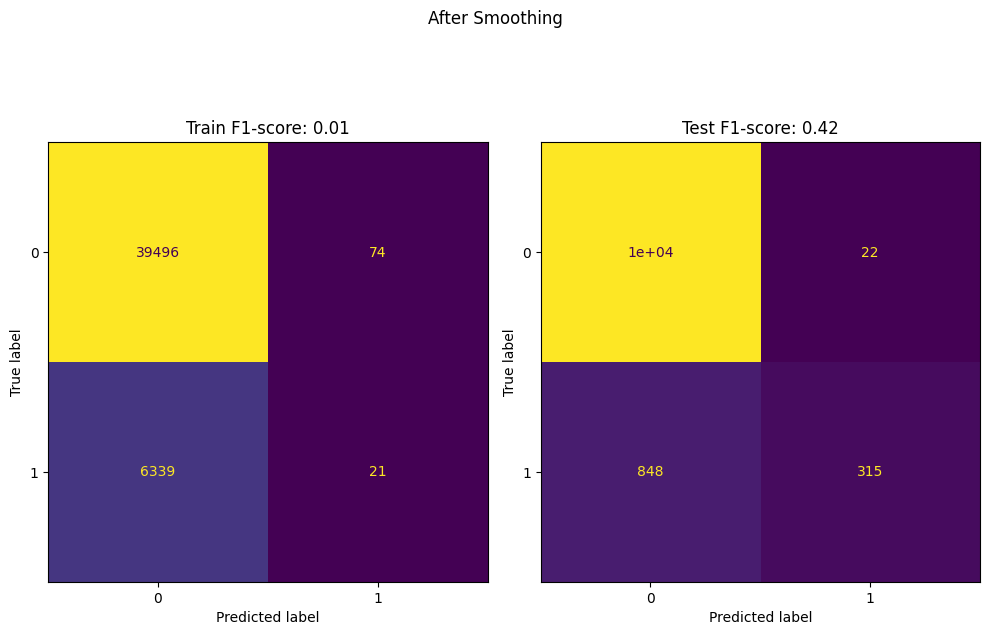

Training epoch 6: 100%|██████████| 1436/1436 [00:20<00:00, 70.11it/s]


Epoch 6 - loss: 0.0305


Training epoch 7: 100%|██████████| 1436/1436 [00:21<00:00, 66.11it/s]


Epoch 7 - loss: 0.0027


Training epoch 8: 100%|██████████| 1436/1436 [00:21<00:00, 67.67it/s]


...

Training epoch 9: 100%|██████████| 1436/1436 [00:21<00:00, 68.16it/s]


Epoch 9 - loss: 0.0243


Training epoch 10: 100%|██████████| 1436/1436 [00:21<00:00, 66.96it/s]


Epoch 10 - loss: 0.0087


Evaluation epoch 10: 100%|██████████| 12/12 [00:01<00:00, 11.51it/s]


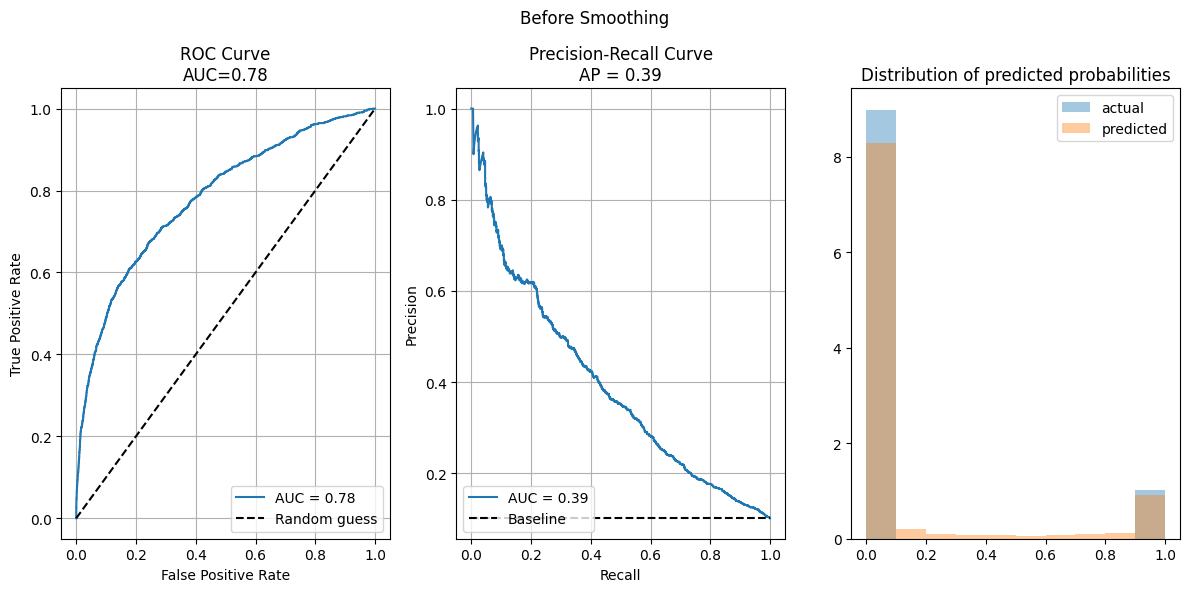

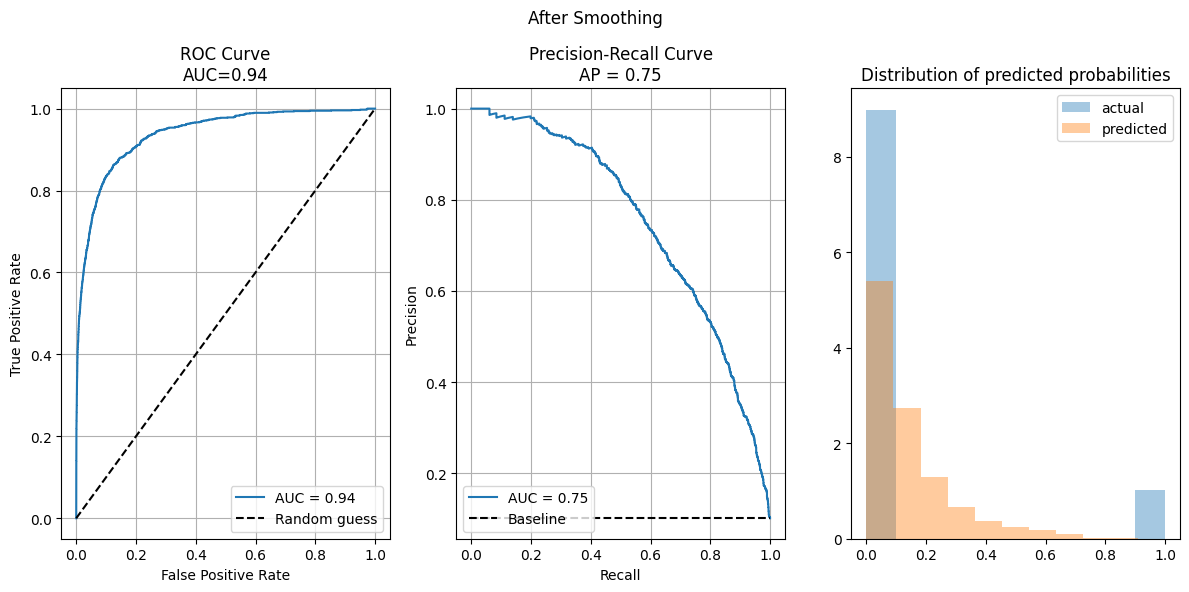

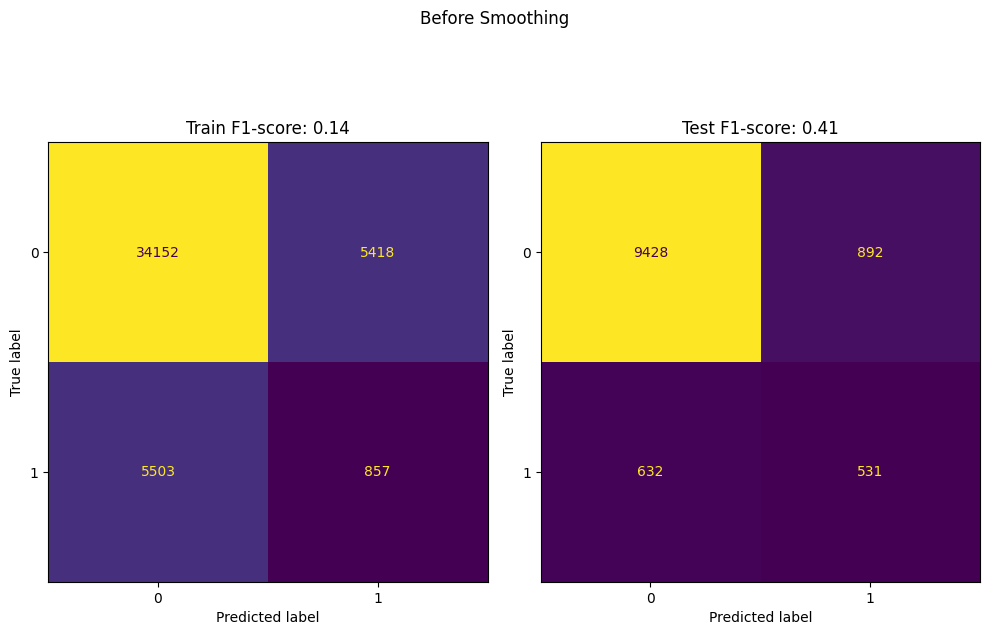

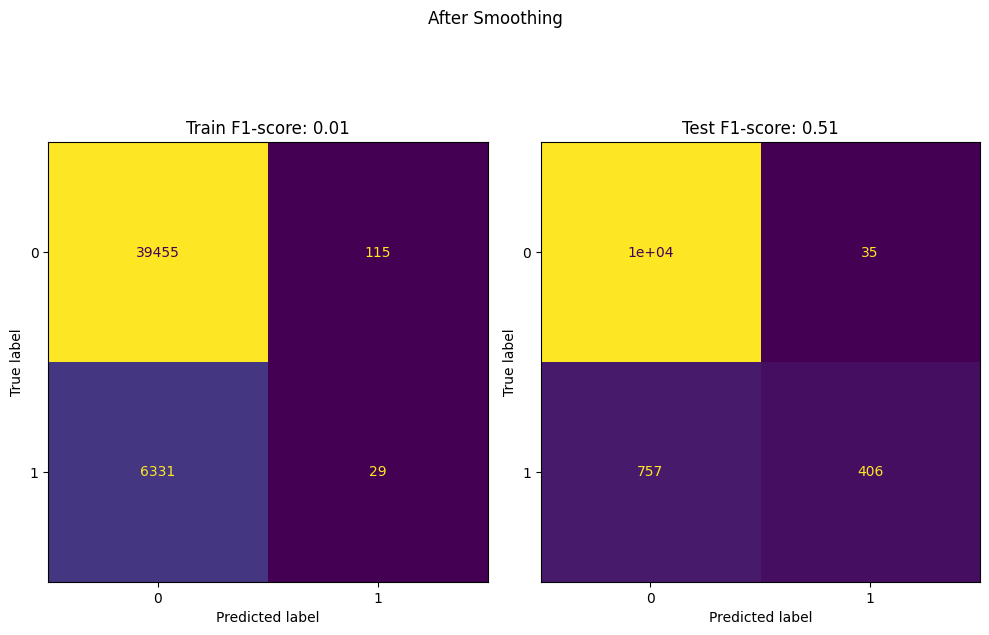

Training epoch 11: 100%|██████████| 1436/1436 [00:19<00:00, 73.58it/s]


Epoch 11 - loss: 0.0104


Training epoch 12: 100%|██████████| 1436/1436 [00:19<00:00, 72.11it/s]


Epoch 12 - loss: 0.0001


Training epoch 13: 100%|██████████| 1436/1436 [00:20<00:00, 71.39it/s]


...

Training epoch 14: 100%|██████████| 1436/1436 [00:21<00:00, 66.39it/s]


Epoch 14 - loss: 0.0017


Training epoch 15: 100%|██████████| 1436/1436 [00:21<00:00, 66.25it/s]


Epoch 15 - loss: 0.0005


Evaluation epoch 15: 100%|██████████| 12/12 [00:00<00:00, 14.24it/s]


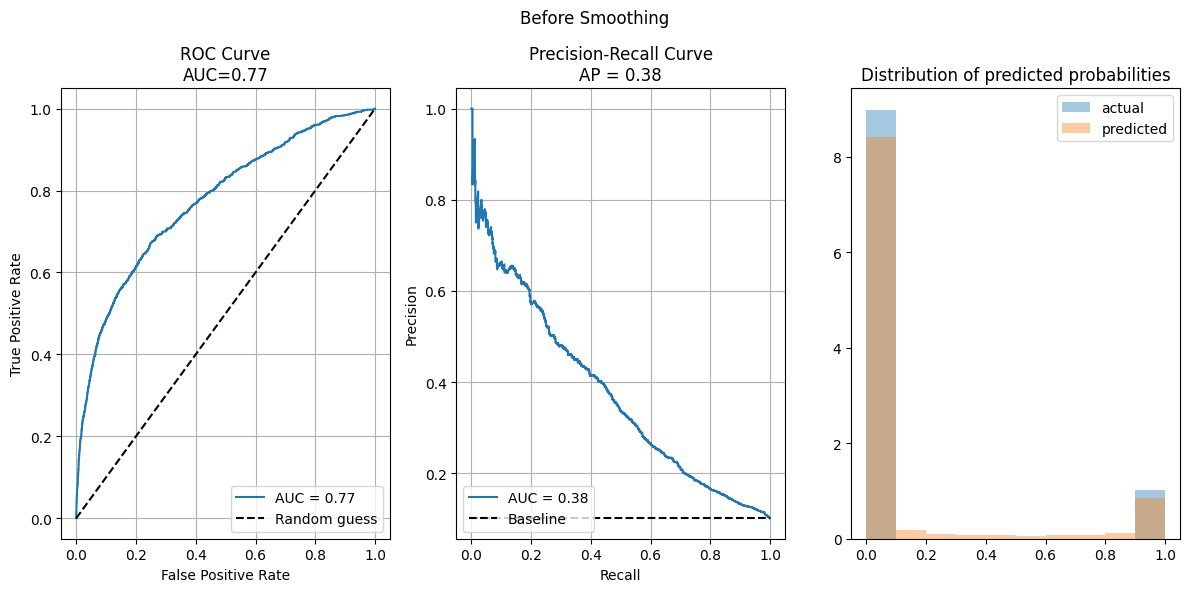

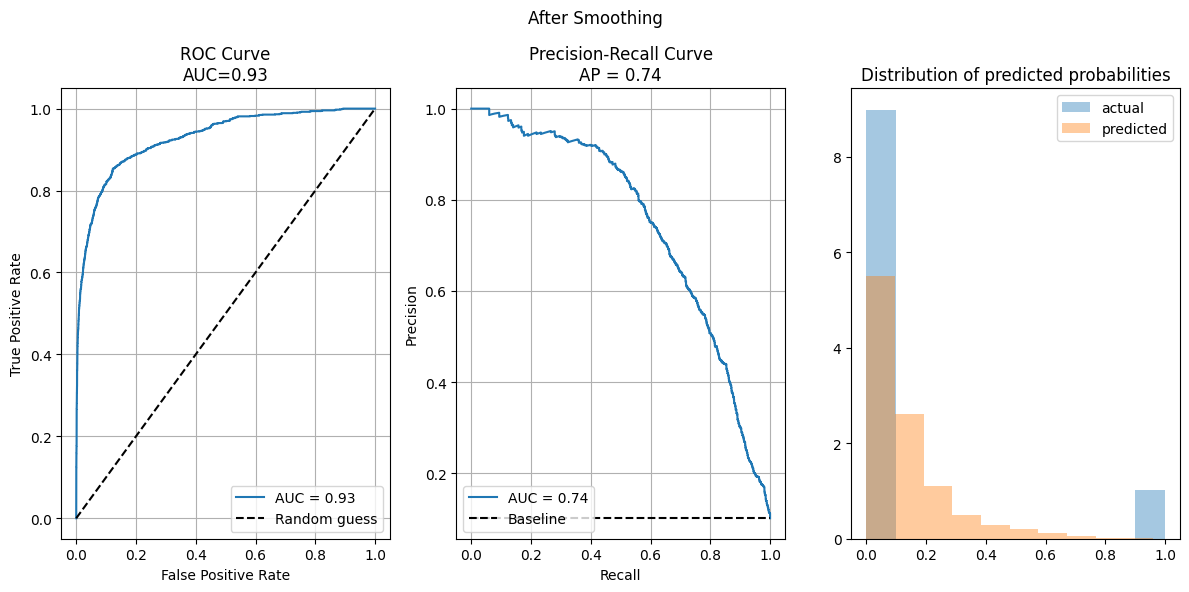

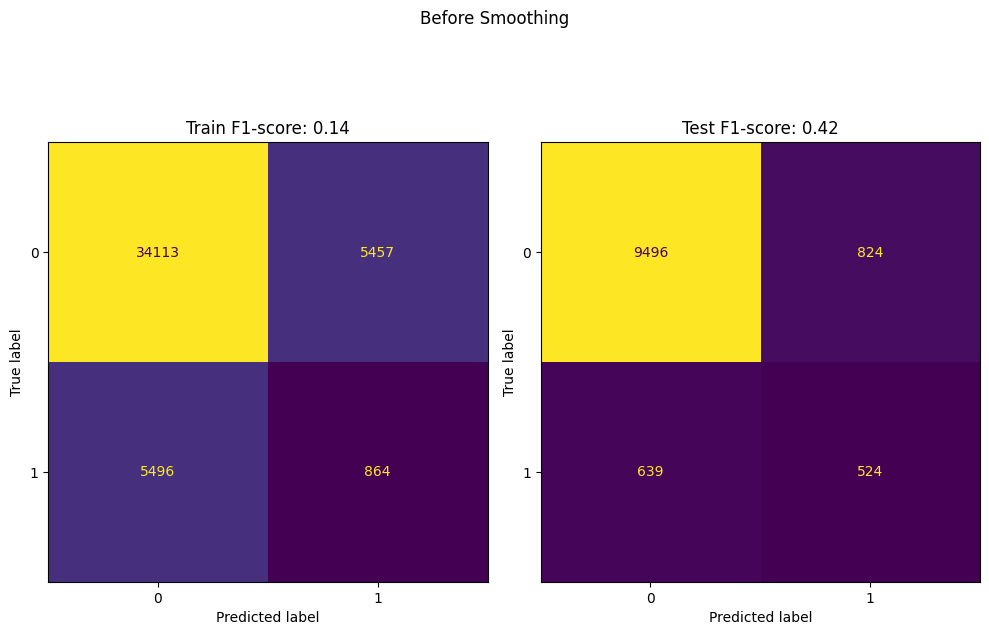

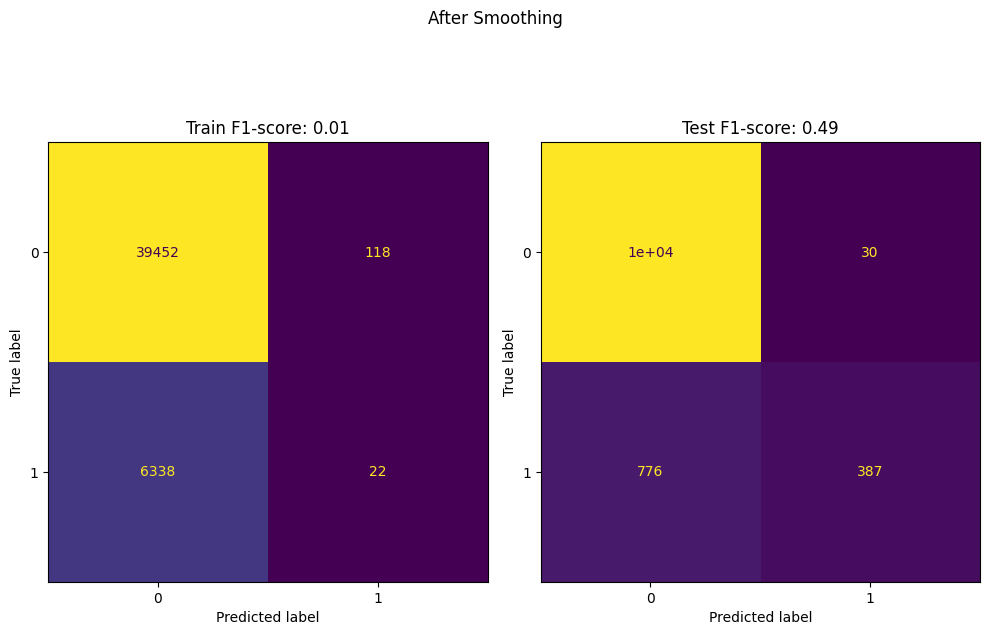

Training epoch 16: 100%|██████████| 1436/1436 [00:21<00:00, 67.00it/s]


Epoch 16 - loss: 0.0037


Training epoch 17: 100%|██████████| 1436/1436 [00:19<00:00, 75.01it/s]


Epoch 17 - loss: 0.0040


Training epoch 18: 100%|██████████| 1436/1436 [00:19<00:00, 74.49it/s]


Epoch 18 - loss: 0.0001


Training epoch 19: 100%|██████████| 1436/1436 [00:19<00:00, 73.94it/s]


Epoch 19 - loss: 0.0013


Evaluation epoch 19: 100%|██████████| 12/12 [00:00<00:00, 13.49it/s]


In [49]:
from torch.utils.data import DataLoader
from tqdm import tqdm

model = RNNClassifier(vocab_size=len(vocab), embed_dim=100, hidden_dim=128)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_pos = sum(label == 1 for label in train_dataset.labels)
num_neg = sum(label == 0 for label in train_dataset.labels)
pos_weight = torch.tensor(num_neg / num_pos, dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=None)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False, collate_fn=collate_fn)

for epoch in range(20):
    model.train()
    y_train_pred = []
    y_test_pred = []
    for x, y in tqdm(train_loader, desc=f"Training epoch {epoch}"):
        logits = model(x)
        loss = criterion(logits, y.float())
        
        y_train_pred.extend(torch.sigmoid(logits).detach().tolist())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} - loss: {loss.item():.4f}")
    
    model.eval()
    with torch.no_grad():
        for x, y in tqdm(test_loader, desc=f"Evaluation epoch {epoch}"):
            logits = model(x)
            y_test_pred.extend(torch.sigmoid(logits).detach().tolist())
            
    y_train_pred = np.array(y_train_pred)
    y_test_pred = np.array(y_test_pred)
    if epoch % 5 == 0:
        # plot_roc_pr(y_test, y_test_pred, title=f"Epoch {epoch} performances")
        # plot_train_test_cm(y_train, y_test, y_train_pred, y_test_pred, title="Before Smoothing")
        
        threshold = 0.4
        y_test_pred_smooth = smooth(adjust_proba(y_test_pred, threshold), size=17)
        y_train_pred_smooth = smooth(adjust_proba(y_train_pred, threshold), size=17)
        plot_roc_pr(y_test, y_test_pred, title="Before Smoothing")
        plot_roc_pr(y_test, y_test_pred_smooth, title="After Smoothing")
        plot_train_test_cm(y_train, y_test, y_train_pred, y_test_pred, title="Before Smoothing")
        plot_train_test_cm(y_train, y_test, y_train_pred_smooth, y_test_pred_smooth, title="After Smoothing")
        # plot_smoothing(y_test, y_test_pred,y_test_pred_smooth ,slc=slice(1000, 2000))